# SigFlow-Sim v2 — Configurable Depth and Training Visualization

Enhancements:

- Adjustable signature depth from a single configuration cell
- Real-time progress bar using tqdm
- Live loss tracking
- Final training curve visualization
- Clean output summary after training


In [29]:
# Install once if needed
!pip install numpy pandas torch matplotlib iisignature nflows yfinance tqdm scikit-learn

## Configuration — Change Model Parameters Here

In [30]:
# Core configuration

WINDOW = 20
DEPTH = 3        # <-- Change signature depth here
USE_LOGSIG = True

EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

print(f"Signature depth set to: {DEPTH}")

Signature depth set to: 3


In [31]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm

import iisignature

from sklearn.metrics.pairwise import rbf_kernel

from nflows.flows import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform

## Load Market Data

In [32]:
import yfinance as yf

ticker = 'AAPL'
data = yf.download(ticker, period='2y')

prices = data['Close']
log_returns = np.log(prices / prices.shift(1)).dropna()

print("Data points:", len(log_returns))

[*********************100%***********************]  1 of 1 completed

Data points: 501


## Signature / Log-Signature Computation

In [33]:
def compute_signature(window):

    t = np.linspace(0, 1, len(window))
    path = np.column_stack([t, window])

    prep = iisignature.prepare(path.shape[1], DEPTH)

    if USE_LOGSIG:
        sig = iisignature.logsig(path, prep)
    else:
        sig = iisignature.sig(path, prep)

    return sig

signatures = []
targets = []

returns_array = log_returns.values

for i in range(WINDOW, len(returns_array) - 1):

    window = returns_array[i-WINDOW:i]

    sig = compute_signature(window)

    signatures.append(sig)
    targets.append(returns_array[i])

X = torch.tensor(np.array(signatures), dtype=torch.float32)
Y = torch.tensor(np.array(targets), dtype=torch.float32).unsqueeze(1)

print("Feature dimension:", X.shape[1])

Feature dimension: 5


## Build Neural Spline Flow

In [34]:
def build_flow(context_dim):

    transforms = []

    for _ in range(4):

        transforms.append(
            MaskedAffineAutoregressiveTransform(
                features=1,
                hidden_features=64,
                context_features=context_dim
            )
        )

    transform = CompositeTransform(transforms)

    base_dist = StandardNormal(shape=[1])

    return Flow(transform, base_dist)


flow = build_flow(X.shape[1])

optimizer = optim.Adam(flow.parameters(), lr=LEARNING_RATE)

In [35]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm

import iisignature

from sklearn.metrics.pairwise import rbf_kernel

from nflows.flows import Flow
from nflows.distributions.normal import StandardNormal
from nflows.transforms.base import CompositeTransform
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform

## Wasserstein Loss

In [36]:
def wasserstein_loss(real, fake):

    real_sorted, _ = torch.sort(real.squeeze())
    fake_sorted, _ = torch.sort(fake.squeeze())

    return torch.mean(torch.abs(real_sorted - fake_sorted))

## Custom Loss

In [41]:
def custom_loss(flow, x_context, y_real):

    log_prob = flow.log_prob(y_real, context=x_context)

    loss_mle = -log_prob.mean()

    y_fake = flow.sample(len(y_real), context=x_context)

    loss_wass = wasserstein_loss(y_real, y_fake)

    variance_fake = torch.var(y_fake)

    loss_div = 1 / (variance_fake + 1e-6)

    return loss_mle + 0.2 * loss_wass + 0.01 * loss_div

#Testing Block
Validates:
    data integrity
    numerical stability
    model forward pass
    sampling correctness

In [42]:
print("\nRUNNING TEST SUITE\n")

assert X.ndim == 2
assert Y.ndim == 2
assert X.shape[0] == Y.shape[0]

assert torch.isfinite(X).all()
assert torch.isfinite(Y).all()

batch_x = X[:16].float().view(-1, X.shape[1])
batch_y = Y[:16].float().view(-1, 1)

loss = custom_loss(flow, batch_x, batch_y)
assert torch.isfinite(loss)

context = X[:1].float()
samples = flow.sample(10, context=context)
assert samples.shape == (10, 1)

print("All tests passed")


RUNNING TEST SUITE



AssertionError: 

## Training with Progress Tracking

In [38]:
loss_history = []

dataset_size = len(X)

for epoch in range(EPOCHS):

    permutation = torch.randperm(dataset_size)

    epoch_loss = 0.0

    progress = tqdm(range(0, dataset_size, BATCH_SIZE), leave=False)

    for i in progress:

        indices = permutation[i:i + BATCH_SIZE]

        batch_x = X[indices].float()
        batch_y = Y[indices].float()


        batch_x = batch_x.view(batch_x.size(0), -1)
        batch_y = batch_y.view(batch_y.size(0), -1)

        optimizer.zero_grad()

        loss = custom_loss(flow, batch_x, batch_y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

        progress.set_description(f"Epoch {epoch + 1}")

    epoch_loss /= (dataset_size / BATCH_SIZE)

    loss_history.append(epoch_loss)

    print(f"Epoch {epoch + 1} | Loss: {epoch_loss:.6f}")

Epoch 1 | Loss: 1.436455


Epoch 2 | Loss: -0.293822


Epoch 3 | Loss: -0.454142


Epoch 4 | Loss: -0.495837


Epoch 5 | Loss: -0.513694


...

Epoch 46 | Loss: -0.547398


Epoch 47 | Loss: -0.546260


Epoch 48 | Loss: -0.549542


Epoch 49 | Loss: -0.543790


Epoch 50 | Loss: -0.537433


## Training Curve Visualization

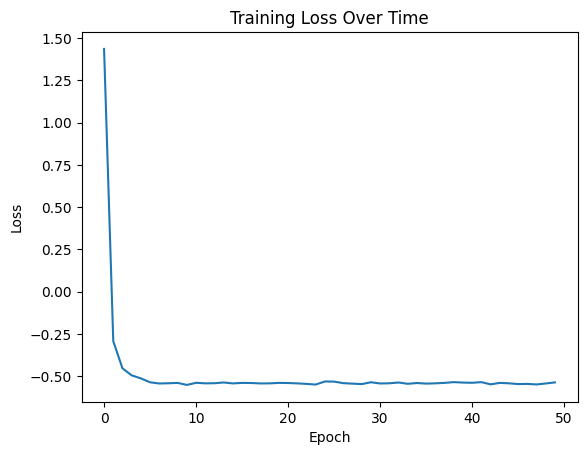

In [39]:
plt.figure()
plt.plot(loss_history)
plt.title("Training Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Posterior Predictive Output

Prediction mean: -0.007587448548787506
Prediction std: 0.1443085273940772


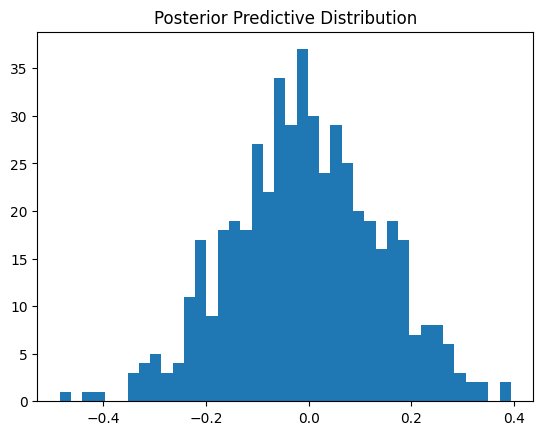

In [40]:
def posterior_predictive(flow, context, n_samples=500):

    samples = []

    for _ in range(n_samples):

        s = flow.sample(1, context=context.unsqueeze(0))

        samples.append(s.item())

    samples = np.array(samples)

    mean = np.mean(samples)
    std = np.std(samples)

    return samples, mean, std

latest_context = X[-1]

samples, mean, std = posterior_predictive(flow, latest_context)

print("Prediction mean:", mean)
print("Prediction std:", std)

plt.figure()
plt.hist(samples, bins=40)
plt.title("Posterior Predictive Distribution")
plt.show()